# Compute average PSD

This notebook builds on the EEG analysis in lab to compute an average PSD for different conditions.

## Step 1
Export all of the **LabChart Text Files (.txt)** for your conditions separately. Then, run the cell below which will create as many folders for you as you have conditions.

In [26]:
# Rename the conditions here!
conditions = ['Control', 'Treatment']

for condition in conditions:
    !mkdir -p {condition}

print("Directories created for conditions: " + ", ".join(conditions))

Directories created for conditions: Control, Treatment


## Step 2
Upload your exported .txt files into their respective folders.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob

filenames = {}

for condition in conditions:
    print(f"Files for {condition}:")
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(filenames[condition])

Files for Control:
['Control/whole brain rest 7.txt', 'Control/whole brain rest 1.txt', 'Control/whole brain rest 2.txt', 'Control/whole brain rest 6.txt', 'Control/whole brain rest 10.txt', 'Control/whole brain rest 3.txt', 'Control/whole brain rest 8.txt', 'Control/whole brain rest 9.txt', 'Control/whole brain rest 5.txt', 'Control/whole brain rest 4.txt']
Files for Treatment:
['Treatment/whole brain math 1.txt', 'Treatment/whole brain math 2.txt', 'Treatment/whole brain math 7.txt', 'Treatment/whole brain math 4.txt', 'Treatment/whole brain math 3.txt', 'Treatment/whole brain math 6.txt', 'Treatment/whole brain math 10.txt', 'Treatment/whole brain math 5.txt', 'Treatment/whole brain math 8.txt', 'Treatment/whole brain math 9.txt']


## Step 3
Run the cell below to define several helper functions. You should also change the sampling frequency if you changed it for some reason.

In [28]:
# Change this if it was different for your experiment!
sampling_freq = 400
nperseg = 800  # Window length in samples (2 seconds at 400 Hz)

def generate_avg_psd(filenames):
  if len(filenames) == 0:
    return np.array([]), np.array([]), np.array([])

  psd_list = []
  freqs = None

  for file in filenames:
    print(file)
    columns = ['time', 'recording']
    data = np.genfromtxt(file, dtype=float, usecols=(0,1), skip_header=6, delimiter='\t', names=columns, encoding='unicode_escape')

    recording = data['recording']

    # Interpolate NaN values
    nans = np.isnan(recording)
    x = np.arange(len(recording))
    recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

    freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)
    psd_list.append(psd_single)

  # Interpolate all PSDs to same length
  max_len = max(len(p) for p in psd_list)
  psd_matrix = np.zeros((max_len, len(filenames)))

  for i, psd in enumerate(psd_list):
    if len(psd) < max_len:
      psd = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(psd)), psd)
    psd_matrix[:, i] = psd

  average_psd = np.mean(psd_matrix, axis=1)
  std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(filenames))

  return average_psd, std_psd, freqs

def plot_psd(average_psd, std_psd, freqs, label=None):
  plt.semilogy(freqs, average_psd, label=label)
  plt.fill_between(freqs, average_psd - std_psd, average_psd + std_psd, alpha=0.3)

  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Power spectral density (µV^2 / Hz)')

  max_freq = 75
  plt.xlim([0, max_freq])

  visible_mask = freqs <= max_freq
  ymin = min((average_psd - std_psd)[visible_mask])
  ymax = max((average_psd + std_psd)[visible_mask])
  plt.ylim(ymin, ymax)

## Step 4
Run the cell below to use the functions to calculate your average PSD and then plot for all of your conditions.

Control/whole brain rest 7.txt
Control/whole brain rest 1.txt
Control/whole brain rest 2.txt
Control/whole brain rest 6.txt
Control/whole brain rest 10.txt
Control/whole brain rest 3.txt
Control/whole brain rest 8.txt
Control/whole brain rest 9.txt
Control/whole brain rest 5.txt
Control/whole brain rest 4.txt
Treatment/whole brain math 1.txt
Treatment/whole brain math 2.txt
Treatment/whole brain math 7.txt
Treatment/whole brain math 4.txt
Treatment/whole brain math 3.txt
Treatment/whole brain math 6.txt
Treatment/whole brain math 10.txt
Treatment/whole brain math 5.txt
Treatment/whole brain math 8.txt
Treatment/whole brain math 9.txt


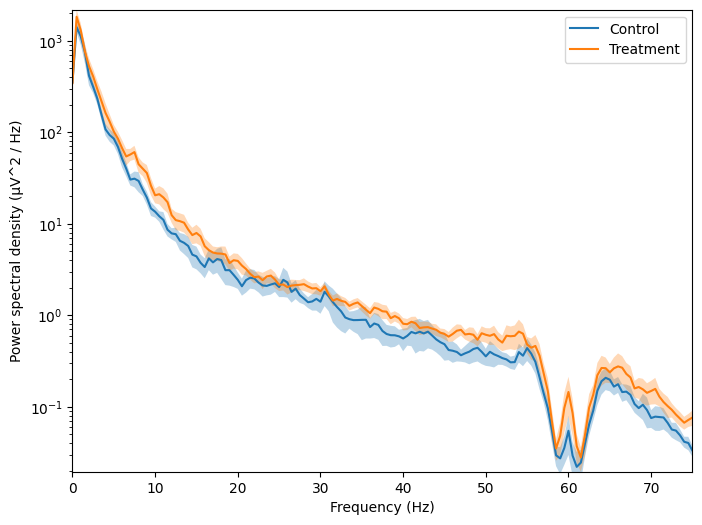

In [29]:
average_psd = {}
std_psd = {}

plt.figure(figsize=(8, 6))

for condition in conditions:
    average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])
    plot_psd(average_psd[condition],std_psd[condition],freqs, label=condition)

plt.legend()
plt.show()

Directories created for conditions: Rest, Math
Files for Rest:
['Rest/whole brain rest 7.txt', 'Rest/whole brain rest 1.txt', 'Rest/whole brain rest 2.txt', 'Rest/whole brain rest 6.txt', 'Rest/whole brain rest 10.txt', 'Rest/whole brain rest 3.txt', 'Rest/whole brain rest 8.txt', 'Rest/whole brain rest 9.txt', 'Rest/whole brain rest 5.txt', 'Rest/whole brain rest 4.txt']
Files for Math:
['Math/whole brain math 1.txt', 'Math/whole brain math 2.txt', 'Math/whole brain math 7.txt', 'Math/whole brain math 4.txt', 'Math/whole brain math 3.txt', 'Math/whole brain math 6.txt', 'Math/whole brain math 10.txt', 'Math/whole brain math 5.txt', 'Math/whole brain math 8.txt', 'Math/whole brain math 9.txt']
Rest/whole brain rest 7.txt
Rest/whole brain rest 1.txt
Rest/whole brain rest 2.txt
Rest/whole brain rest 6.txt
Rest/whole brain rest 10.txt
Rest/whole brain rest 3.txt
Rest/whole brain rest 8.txt
Rest/whole brain rest 9.txt
Rest/whole brain rest 5.txt
Rest/whole brain rest 4.txt
Rest peak (7–10 

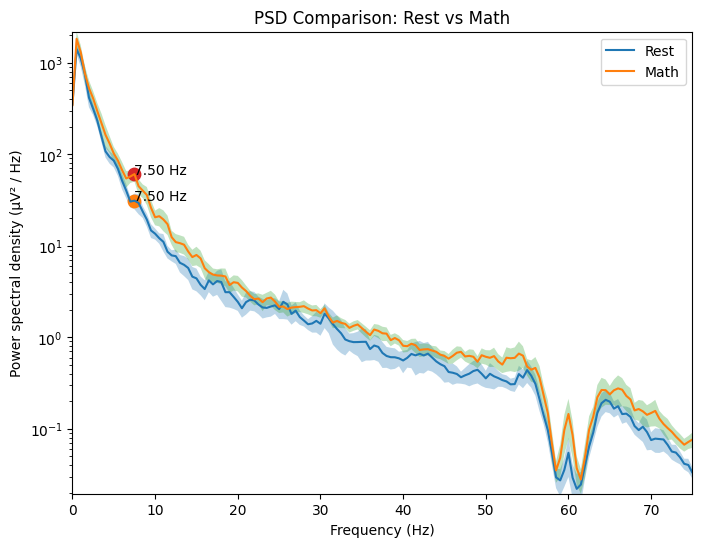

In [39]:
# Rename the conditions here!
conditions = ['Rest', 'Math']

import os
for condition in conditions:
    os.makedirs(condition, exist_ok=True)

print("Directories created for conditions: " + ", ".join(conditions))


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob


# Get filenames
filenames = {}

for condition in conditions:
    print(f"Files for {condition}:")
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(filenames[condition])


# Experiment parameters
sampling_freq = 400
nperseg = 800  # Window length in samples (2 seconds at 400 Hz)


def generate_avg_psd(filenames):

  if len(filenames) == 0:
    return np.array([]), np.array([]), np.array([])

  psd_list = []
  freqs = None

  for file in filenames:

    print(file)

    columns = ['time', 'recording']

    data = np.genfromtxt(
        file,
        dtype=float,
        usecols=(0,1),
        skip_header=6,
        delimiter='\t',
        names=columns,
        encoding='unicode_escape'
    )

    recording = data['recording']

    # Interpolate NaN values
    nans = np.isnan(recording)
    x = np.arange(len(recording))
    recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

    freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)

    psd_list.append(psd_single)


  # Interpolate PSDs to same length
  max_len = max(len(p) for p in psd_list)
  psd_matrix = np.zeros((max_len, len(psd_list)))

  for i, psd in enumerate(psd_list):

    if len(psd) < max_len:
      psd = np.interp(
          np.linspace(0,1,max_len),
          np.linspace(0,1,len(psd)),
          psd
      )

    psd_matrix[:,i] = psd


  average_psd = np.mean(psd_matrix, axis=1)
  std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(psd_list))

  return average_psd, std_psd, freqs



def plot_psd(average_psd, std_psd, freqs, label=None):

  plt.semilogy(freqs, average_psd, label=label)

  plt.fill_between(
      freqs,
      average_psd - std_psd,
      average_psd + std_psd,
      alpha=0.3
  )

  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Power spectral density (µV² / Hz)')

  max_freq = 75
  plt.xlim([0, max_freq])

  visible_mask = freqs <= max_freq
  ymin = min((average_psd - std_psd)[visible_mask])
  ymax = max((average_psd + std_psd)[visible_mask])

  plt.ylim(ymin, ymax)



# Function to find peak in 5–10 Hz range
def find_peak(freqs, psd, fmin=7, fmax=10):

  mask = (freqs >= fmin) & (freqs <= fmax)

  freqs_band = freqs[mask]
  psd_band = psd[mask]

  peak_index = np.argmax(psd_band)

  peak_freq = freqs_band[peak_index]
  peak_power = psd_band[peak_index]

  return peak_freq, peak_power



average_psd = {}
std_psd = {}

plt.figure(figsize=(8,6))


for condition in conditions:

  average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])

  # Skip if no files exist
  if len(average_psd[condition]) == 0:
    print(f"No files found for {condition}")
    continue

  plot_psd(average_psd[condition], std_psd[condition], freqs, label=condition)

  # Find peak between 5–10 Hz
  peak_freq, peak_power = find_peak(freqs, average_psd[condition])

  print(f"{condition} peak (7–10 Hz): {peak_freq:.2f} Hz")

  # Mark peak on graph
  plt.scatter(peak_freq, peak_power, s=80)
  plt.text(peak_freq, peak_power, f"{peak_freq:.2f} Hz")


plt.legend()
plt.title("PSD Comparison: Rest vs Math")
plt.show()

Directories created for conditions: Rest, Math
Files for Rest:
['Rest/whole brain rest 7.txt', 'Rest/whole brain rest 1.txt', 'Rest/whole brain rest 2.txt', 'Rest/whole brain rest 6.txt', 'Rest/whole brain rest 10.txt', 'Rest/whole brain rest 3.txt', 'Rest/whole brain rest 8.txt', 'Rest/whole brain rest 9.txt', 'Rest/whole brain rest 5.txt', 'Rest/whole brain rest 4.txt']
Files for Math:
['Math/whole brain math 1.txt', 'Math/whole brain math 2.txt', 'Math/whole brain math 7.txt', 'Math/whole brain math 4.txt', 'Math/whole brain math 3.txt', 'Math/whole brain math 6.txt', 'Math/whole brain math 10.txt', 'Math/whole brain math 5.txt', 'Math/whole brain math 8.txt', 'Math/whole brain math 9.txt']
Rest/whole brain rest 7.txt
Rest/whole brain rest 1.txt
Rest/whole brain rest 2.txt
Rest/whole brain rest 6.txt
Rest/whole brain rest 10.txt
Rest/whole brain rest 3.txt
Rest/whole brain rest 8.txt
Rest/whole brain rest 9.txt
Rest/whole brain rest 5.txt
Rest/whole brain rest 4.txt
Rest power near 

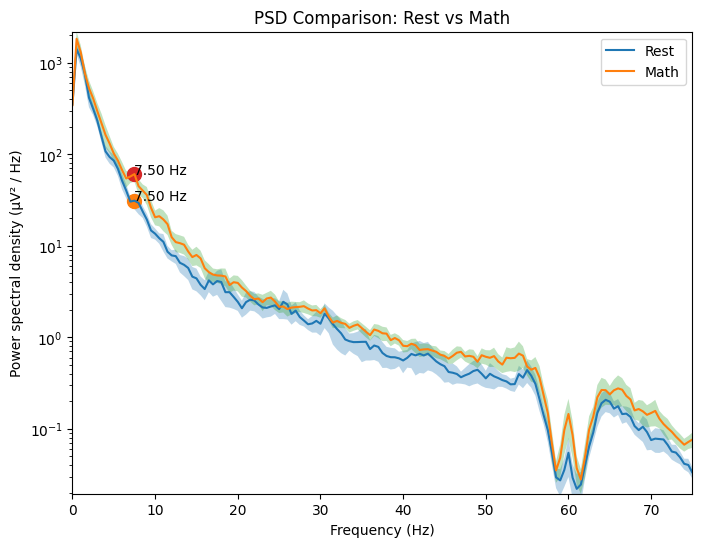

In [40]:
# Rename the conditions here!
conditions = ['Rest', 'Math']

import os
for condition in conditions:
    os.makedirs(condition, exist_ok=True)

print("Directories created for conditions: " + ", ".join(conditions))


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob


# Get filenames
filenames = {}

for condition in conditions:
    print(f"Files for {condition}:")
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(filenames[condition])


# Experiment parameters
sampling_freq = 400
nperseg = 800  # Window length in samples (2 seconds at 400 Hz)


def generate_avg_psd(filenames):

  if len(filenames) == 0:
    return np.array([]), np.array([]), np.array([])

  psd_list = []
  freqs = None

  for file in filenames:

    print(file)

    columns = ['time', 'recording']

    data = np.genfromtxt(
        file,
        dtype=float,
        usecols=(0,1),
        skip_header=6,
        delimiter='\t',
        names=columns,
        encoding='unicode_escape'
    )

    recording = data['recording']

    # Interpolate NaN values
    nans = np.isnan(recording)
    x = np.arange(len(recording))
    recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

    freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)

    psd_list.append(psd_single)


  # Interpolate PSDs to same length
  max_len = max(len(p) for p in psd_list)
  psd_matrix = np.zeros((max_len, len(psd_list)))

  for i, psd in enumerate(psd_list):

    if len(psd) < max_len:
      psd = np.interp(
          np.linspace(0,1,max_len),
          np.linspace(0,1,len(psd)),
          psd
      )

    psd_matrix[:,i] = psd


  average_psd = np.mean(psd_matrix, axis=1)
  std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(psd_list))

  return average_psd, std_psd, freqs



def plot_psd(average_psd, std_psd, freqs, label=None):

  plt.semilogy(freqs, average_psd, label=label)

  plt.fill_between(
      freqs,
      average_psd - std_psd,
      average_psd + std_psd,
      alpha=0.3
  )

  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Power spectral density (µV² / Hz)')

  max_freq = 75
  plt.xlim([0, max_freq])

  visible_mask = freqs <= max_freq
  ymin = min((average_psd - std_psd)[visible_mask])
  ymax = max((average_psd + std_psd)[visible_mask])

  plt.ylim(ymin, ymax)


# Function to get power near 7.50 Hz
def get_power_at_frequency(freqs, psd, target_freq=7.5):

  idx = np.argmin(np.abs(freqs - target_freq))

  freq_value = freqs[idx]
  power_value = psd[idx]

  return freq_value, power_value



average_psd = {}
std_psd = {}

plt.figure(figsize=(8,6))


for condition in conditions:

  average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])

  # Skip if no files
  if len(average_psd[condition]) == 0:
    print(f"No files found for {condition}")
    continue

  plot_psd(average_psd[condition], std_psd[condition], freqs, label=condition)

  # Get power at ~7.50 Hz
  freq_val, power_val = get_power_at_frequency(freqs, average_psd[condition], 7.5)

  print(f"{condition} power near 7.50 Hz: {power_val:.4f}")

  # Plot dot
  plt.scatter(freq_val, power_val, s=100)
  plt.text(freq_val, power_val, "7.50 Hz")


plt.legend()
plt.title("PSD Comparison: Rest vs Math")
plt.show()

Directories created for conditions: Rest, Math
Rest: 10 files
Math: 10 files


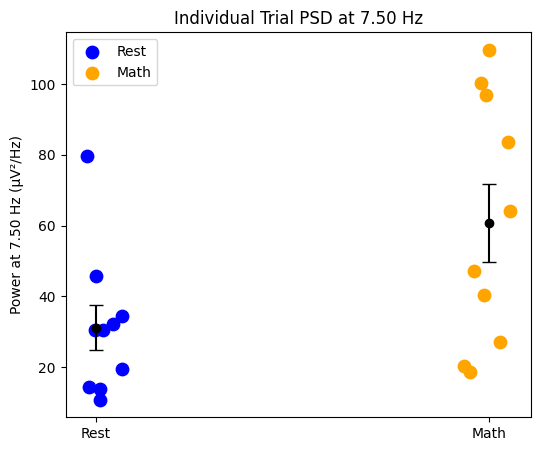

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os

# Conditions
conditions = ['Rest', 'Math']
for condition in conditions:
    os.makedirs(condition, exist_ok=True)

print("Directories created for conditions: " + ", ".join(conditions))

# Parameters
sampling_freq = 400
nperseg = 800  # 2 seconds

# Get filenames
filenames = {}
for condition in conditions:
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(f"{condition}: {len(filenames[condition])} files")

# Function to compute PSD
def compute_psd(file):
    columns = ['time', 'recording']
    data = np.genfromtxt(
        file,
        dtype=float,
        usecols=(0,1),
        skip_header=6,
        delimiter='\t',
        names=columns,
        encoding='unicode_escape'
    )
    recording = data['recording']
    # Interpolate NaNs
    nans = np.isnan(recording)
    x = np.arange(len(recording))
    recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])
    freqs, psd = signal.welch(recording, sampling_freq, nperseg=nperseg)
    return freqs, psd

# Function to get power at ~7.50 Hz
def get_power_at_frequency(freqs, psd, target_freq=7.5):
    idx = np.argmin(np.abs(freqs - target_freq))
    return psd[idx]

# Collect individual trial powers
trial_powers = {cond: [] for cond in conditions}

for condition in conditions:
    for file in filenames[condition]:
        freqs, psd = compute_psd(file)
        power_7_5 = get_power_at_frequency(freqs, psd, 7.5)
        trial_powers[condition].append(power_7_5)

# Dot plot
plt.figure(figsize=(6,5))
colors = ['blue','orange']
for i, condition in enumerate(conditions):
    # x positions jittered for visibility
    x = np.random.normal(i+1, 0.05, size=len(trial_powers[condition]))
    plt.scatter(x, trial_powers[condition], color=colors[i], label=condition, s=80)

    # mean ± SEM
    mean_power = np.mean(trial_powers[condition])
    sem_power = np.std(trial_powers[condition], ddof=1)/np.sqrt(len(trial_powers[condition]))
    plt.errorbar(i+1, mean_power, yerr=sem_power, fmt='o', color='black', capsize=5)

plt.xticks([1,2], conditions)
plt.ylabel("Power at 7.50 Hz (µV²/Hz)")
plt.title("Individual Trial PSD at 7.50 Hz")
plt.legend()
plt.show()

In [44]:
# Collect individual trial powers and print them as a list
trial_powers = {cond: [] for cond in conditions}

for condition in conditions:
    for file in filenames[condition]:
        freqs, psd = compute_psd(file)
        power_7_5 = get_power_at_frequency(freqs, psd, 7.5)
        trial_powers[condition].append(power_7_5)

    # Print values as a list
    print(f"{condition} individual trial powers at 7.50 Hz:")
    print([round(p, 4) for p in trial_powers[condition]])
    print()

Rest individual trial powers at 7.50 Hz:
[np.float64(14.4802), np.float64(79.6669), np.float64(34.4718), np.float64(19.3361), np.float64(30.5214), np.float64(10.7568), np.float64(45.6588), np.float64(32.2844), np.float64(13.8997), np.float64(30.4529)]

Math individual trial powers at 7.50 Hz:
[np.float64(83.4965), np.float64(47.1966), np.float64(100.2842), np.float64(109.6772), np.float64(96.7858), np.float64(18.4824), np.float64(64.1847), np.float64(20.1677), np.float64(27.2034), np.float64(40.3622)]



In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob

# Define the folders
conditions = ['Rest1', 'Math1']

# Get filenames
filenames = {}
for condition in conditions:
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(f"Files for {condition}: {filenames[condition]}")

# PSD parameters
sampling_freq = 400
nperseg = 800  # 2-second window at 400 Hz

# Function to generate average PSD per condition
def generate_avg_psd(filenames):
    if len(filenames) == 0:
        return np.array([]), np.array([]), np.array([])

    psd_list = []
    for file in filenames:
        columns = ['time','recording']
        data = np.genfromtxt(file, dtype=float, usecols=(0,1), skip_header=6, delimiter='\t', names=columns, encoding='unicode_escape')
        recording = data['recording']

        # Interpolate NaNs
        nans = np.isnan(recording)
        x = np.arange(len(recording))
        recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

        freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)
        psd_list.append(psd_single)

    # Interpolate to same length
    max_len = max(len(p) for p in psd_list)
    psd_matrix = np.zeros((max_len, len(filenames)))
    for i, psd in enumerate(psd_list):
        if len(psd) < max_len:
            psd = np.interp(np.linspace(0,1,max_len), np.linspace(0,1,len(psd)), psd)
        psd_matrix[:,i] = psd

    average_psd = np.mean(psd_matrix, axis=1)
    std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(filenames))
    return average_psd, std_psd, freqs

# Generate PSDs
average_psd = {}
std_psd = {}
for condition in conditions:
    average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])

# Extract individual trial powers at 7.5 Hz
target_freq = 7.5
trial_powers = {}
for condition in conditions:
    trial_powers[condition] = []
    for file in filenames[condition]:
        columns = ['time','recording']
        data = np.genfromtxt(file, dtype=float, usecols=(0,1), skip_header=6, delimiter='\t', names=columns, encoding='unicode_escape')
        recording = data['recording']
        nans = np.isnan(recording)
        x = np.arange(len(recording))
        recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])
        freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)
        # Interpolate PSD to exact freq
        psd_at_target = np.interp(target_freq, freqs, psd_single)
        trial_powers[condition].append(psd_at_target)

# Print the trial powers
for condition in conditions:
    print(f"{condition} individual trial powers at {target_freq} Hz:")
    print(trial_powers[condition])

Files for Rest1: ['Rest1/Occipital rest 2.txt', 'Rest1/Occipital rest 9.txt', 'Rest1/Occipital rest 8.txt', 'Rest1/Occipital rest 1.txt', 'Rest1/Occipital rest 3.txt', 'Rest1/Occipital rest 6.txt', 'Rest1/Occipital rest 7.txt', 'Rest1/Occipital rest 4.txt', 'Rest1/Occipital rest 10.txt', 'Rest1/Occipital rest 5.txt']
Files for Math1: ['Math1/Occipital math 5.txt', 'Math1/Occipital math 8.txt', 'Math1/Occipital math 7.txt', 'Math1/Occipital math 6.txt', 'Math1/Occipital math 9.txt', 'Math1/Occipital math 3.txt', 'Math1/Occipital math 4.txt', 'Math1/Occipital math 10.txt', 'Math1/Occipital math 1.txt', 'Math1/Occipital math 2.txt']
Rest1 individual trial powers at 7.5 Hz:
[np.float64(5.888878908728551), np.float64(3.23381660636675), np.float64(4.089950568187738), np.float64(14.233057137364879), np.float64(18.425553150199473), np.float64(11.076551489622748), np.float64(1.6639704491322371), np.float64(4.635042733965621), np.float64(20.099783554379883), np.float64(2.580145025573701)]
Math1 

Directories created for conditions: Rest, Math
Files for Rest:
['Rest/whole brain rest 7.txt', 'Rest/whole brain rest 1.txt', 'Rest/whole brain rest 2.txt', 'Rest/whole brain rest 6.txt', 'Rest/whole brain rest 10.txt', 'Rest/whole brain rest 3.txt', 'Rest/whole brain rest 8.txt', 'Rest/whole brain rest 9.txt', 'Rest/whole brain rest 5.txt', 'Rest/whole brain rest 4.txt']
Files for Math:
['Math/whole brain math 1.txt', 'Math/whole brain math 2.txt', 'Math/whole brain math 7.txt', 'Math/whole brain math 4.txt', 'Math/whole brain math 3.txt', 'Math/whole brain math 6.txt', 'Math/whole brain math 10.txt', 'Math/whole brain math 5.txt', 'Math/whole brain math 8.txt', 'Math/whole brain math 9.txt']
Rest/whole brain rest 7.txt
Rest/whole brain rest 1.txt
Rest/whole brain rest 2.txt
Rest/whole brain rest 6.txt
Rest/whole brain rest 10.txt
Rest/whole brain rest 3.txt
Rest/whole brain rest 8.txt
Rest/whole brain rest 9.txt
Rest/whole brain rest 5.txt
Rest/whole brain rest 4.txt
Rest power near 

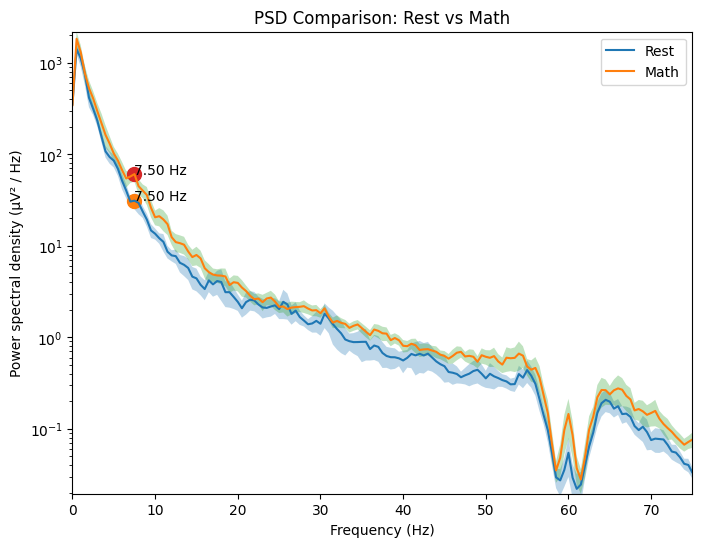

In [50]:
# Rename the conditions here!
conditions = ['Rest', 'Math']

import os
for condition in conditions:
    os.makedirs(condition, exist_ok=True)

print("Directories created for conditions: " + ", ".join(conditions))


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob


# Get filenames
filenames = {}

for condition in conditions:
    print(f"Files for {condition}:")
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(filenames[condition])


# Experiment parameters
sampling_freq = 400
nperseg = 800  # Window length in samples (2 seconds at 400 Hz)


def generate_avg_psd(filenames):

  if len(filenames) == 0:
    return np.array([]), np.array([]), np.array([])

  psd_list = []
  freqs = None

  for file in filenames:

    print(file)

    columns = ['time', 'recording']

    data = np.genfromtxt(
        file,
        dtype=float,
        usecols=(0,1),
        skip_header=6,
        delimiter='\t',
        names=columns,
        encoding='unicode_escape'
    )

    recording = data['recording']

    # Interpolate NaN values
    nans = np.isnan(recording)
    x = np.arange(len(recording))
    recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

    freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)

    psd_list.append(psd_single)


  # Interpolate PSDs to same length
  max_len = max(len(p) for p in psd_list)
  psd_matrix = np.zeros((max_len, len(psd_list)))

  for i, psd in enumerate(psd_list):

    if len(psd) < max_len:
      psd = np.interp(
          np.linspace(0,1,max_len),
          np.linspace(0,1,len(psd)),
          psd
      )

    psd_matrix[:,i] = psd


  average_psd = np.mean(psd_matrix, axis=1)
  std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(psd_list))

  return average_psd, std_psd, freqs



def plot_psd(average_psd, std_psd, freqs, label=None):

  plt.semilogy(freqs, average_psd, label=label)

  plt.fill_between(
      freqs,
      average_psd - std_psd,
      average_psd + std_psd,
      alpha=0.3
  )

  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Power spectral density (µV² / Hz)')

  max_freq = 75
  plt.xlim([0, max_freq])

  visible_mask = freqs <= max_freq
  ymin = min((average_psd - std_psd)[visible_mask])
  ymax = max((average_psd + std_psd)[visible_mask])

  plt.ylim(ymin, ymax)


# Function to get power near 7.50 Hz
def get_power_at_frequency(freqs, psd, target_freq=7.5):

  idx = np.argmin(np.abs(freqs - target_freq))

  freq_value = freqs[idx]
  power_value = psd[idx]

  return freq_value, power_value



average_psd = {}
std_psd = {}

plt.figure(figsize=(8,6))


for condition in conditions:

  average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])

  # Skip if no files
  if len(average_psd[condition]) == 0:
    print(f"No files found for {condition}")
    continue

  plot_psd(average_psd[condition], std_psd[condition], freqs, label=condition)

  # Get power at ~7.50 Hz
  freq_val, power_val = get_power_at_frequency(freqs, average_psd[condition], 7.5)

  print(f"{condition} power near 7.50 Hz: {power_val:.4f}")

  # Plot dot
  plt.scatter(freq_val, power_val, s=100)
  plt.text(freq_val, power_val, "7.50 Hz")


plt.legend()
plt.title("PSD Comparison: Rest vs Math")
plt.show()

Directories created for conditions: Rest1, Math1
Files for Rest1:
['Rest1/Occipital rest 2.txt', 'Rest1/Occipital rest 9.txt', 'Rest1/Occipital rest 8.txt', 'Rest1/Occipital rest 1.txt', 'Rest1/Occipital rest 3.txt', 'Rest1/Occipital rest 6.txt', 'Rest1/Occipital rest 7.txt', 'Rest1/Occipital rest 4.txt', 'Rest1/Occipital rest 10.txt', 'Rest1/Occipital rest 5.txt']
Files for Math1:
['Math1/Occipital math 5.txt', 'Math1/Occipital math 8.txt', 'Math1/Occipital math 7.txt', 'Math1/Occipital math 6.txt', 'Math1/Occipital math 9.txt', 'Math1/Occipital math 3.txt', 'Math1/Occipital math 4.txt', 'Math1/Occipital math 10.txt', 'Math1/Occipital math 1.txt', 'Math1/Occipital math 2.txt']
Rest1/Occipital rest 2.txt
Rest1/Occipital rest 9.txt
Rest1/Occipital rest 8.txt
Rest1/Occipital rest 1.txt
Rest1/Occipital rest 3.txt
Rest1/Occipital rest 6.txt
Rest1/Occipital rest 7.txt
Rest1/Occipital rest 4.txt
Rest1/Occipital rest 10.txt
Rest1/Occipital rest 5.txt
Rest1 power near 7.50 Hz: 8.5927
Math1/Occ

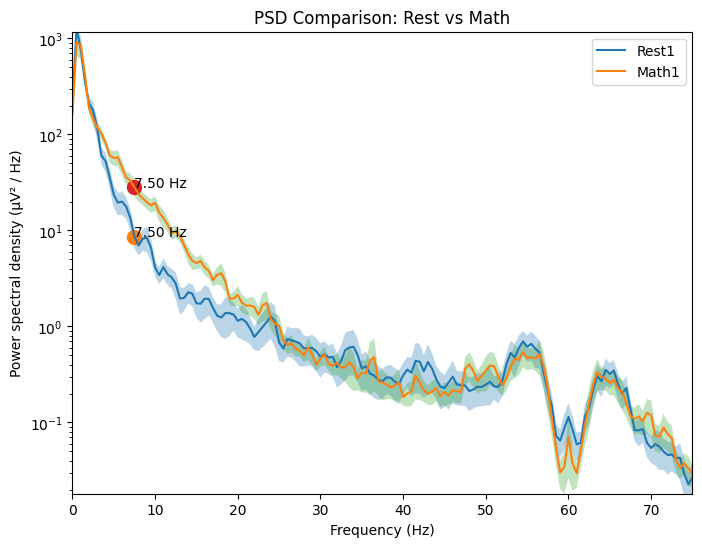

In [58]:
# Rename the conditions here!
conditions = ['Rest1', 'Math1']

import os
for condition in conditions:
    os.makedirs(condition, exist_ok=True)

print("Directories created for conditions: " + ", ".join(conditions))


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob


# Get filenames
filenames = {}

for condition in conditions:
    print(f"Files for {condition}:")
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(filenames[condition])


# Experiment parameters
sampling_freq = 400
nperseg = 800  # Window length in samples (2 seconds at 400 Hz)


def generate_avg_psd(filenames):

  if len(filenames) == 0:
    return np.array([]), np.array([]), np.array([])

  psd_list = []
  freqs = None

  for file in filenames:

    print(file)

    columns = ['time', 'recording']

    data = np.genfromtxt(
        file,
        dtype=float,
        usecols=(0,1),
        skip_header=6,
        delimiter='\t',
        names=columns,
        encoding='unicode_escape'
    )

    recording = data['recording']

    # Interpolate NaN values
    nans = np.isnan(recording)
    x = np.arange(len(recording))
    recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

    freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)

    psd_list.append(psd_single)


  # Interpolate PSDs to same length
  max_len = max(len(p) for p in psd_list)
  psd_matrix = np.zeros((max_len, len(psd_list)))

  for i, psd in enumerate(psd_list):

    if len(psd) < max_len:
      psd = np.interp(
          np.linspace(0,1,max_len),
          np.linspace(0,1,len(psd)),
          psd
      )

    psd_matrix[:,i] = psd


  average_psd = np.mean(psd_matrix, axis=1)
  std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(psd_list))

  return average_psd, std_psd, freqs



def plot_psd(average_psd, std_psd, freqs, label=None):

  plt.semilogy(freqs, average_psd, label=label)

  plt.fill_between(
      freqs,
      average_psd - std_psd,
      average_psd + std_psd,
      alpha=0.3
  )

  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Power spectral density (µV² / Hz)')

  max_freq = 75
  plt.xlim([0, max_freq])

  visible_mask = freqs <= max_freq
  ymin = min((average_psd - std_psd)[visible_mask])
  ymax = max((average_psd + std_psd)[visible_mask])

  plt.ylim(ymin, ymax)


# Function to get power near 7.50 Hz
def get_power_at_frequency(freqs, psd, target_freq=7.5):

  idx = np.argmin(np.abs(freqs - target_freq))

  freq_value = freqs[idx]
  power_value = psd[idx]

  return freq_value, power_value



average_psd = {}
std_psd = {}

plt.figure(figsize=(8,6))


for condition in conditions:

  average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])

  # Skip if no files
  if len(average_psd[condition]) == 0:
    print(f"No files found for {condition}")
    continue

  plot_psd(average_psd[condition], std_psd[condition], freqs, label=condition)

  # Get power at ~7.50 Hz
  freq_val, power_val = get_power_at_frequency(freqs, average_psd[condition], 7.5)

  print(f"{condition} power near 7.50 Hz: {power_val:.4f}")

  # Plot dot
  plt.scatter(freq_val, power_val, s=100)
  plt.text(freq_val, power_val, "7.50 Hz")


plt.legend()
plt.title("PSD Comparison: Rest vs Math")
plt.show()

Directories created for conditions: Rest1, Math1
Files for Rest1: ['Rest1/Occipital rest 2.txt', 'Rest1/Occipital rest 9.txt', 'Rest1/Occipital rest 8.txt', 'Rest1/Occipital rest 1.txt', 'Rest1/Occipital rest 3.txt', 'Rest1/Occipital rest 6.txt', 'Rest1/Occipital rest 7.txt', 'Rest1/Occipital rest 4.txt', 'Rest1/Occipital rest 10.txt', 'Rest1/Occipital rest 5.txt']
Files for Math1: ['Math1/Occipital math 5.txt', 'Math1/Occipital math 8.txt', 'Math1/Occipital math 7.txt', 'Math1/Occipital math 6.txt', 'Math1/Occipital math 9.txt', 'Math1/Occipital math 3.txt', 'Math1/Occipital math 4.txt', 'Math1/Occipital math 10.txt', 'Math1/Occipital math 1.txt', 'Math1/Occipital math 2.txt']
Processing: Rest1/Occipital rest 2.txt
Processing: Rest1/Occipital rest 9.txt
Processing: Rest1/Occipital rest 8.txt
Processing: Rest1/Occipital rest 1.txt
Processing: Rest1/Occipital rest 3.txt
Processing: Rest1/Occipital rest 6.txt
Processing: Rest1/Occipital rest 7.txt
Processing: Rest1/Occipital rest 4.txt
P

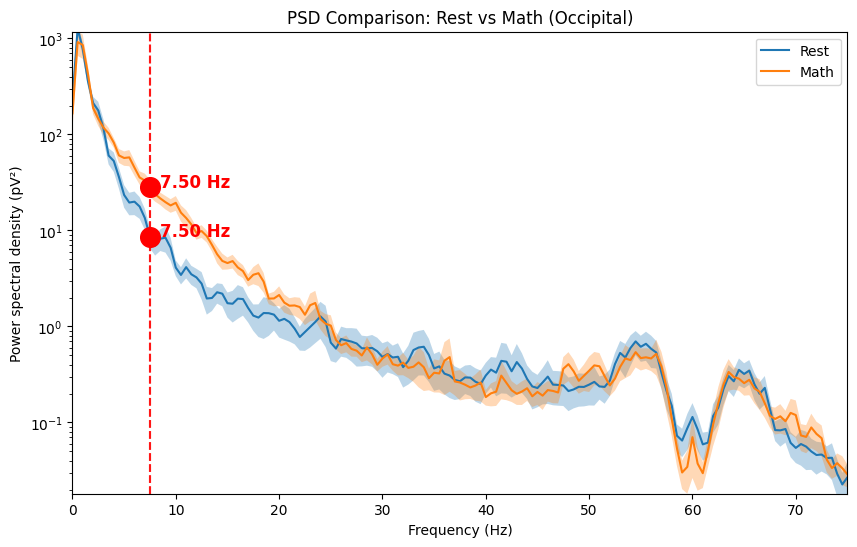

In [67]:
# Full PSD plot for Rest1 vs Math1 focusing on 7.50 Hz (with legend labels changed)

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob

# --- Conditions / folders ---
conditions = ['Rest1', 'Math1']
legend_labels = {'Rest1': 'Rest', 'Math1': 'Math'}  # mapping for legend

# Create folders if they don't exist (optional)
for condition in conditions:
    os.makedirs(condition, exist_ok=True)
print("Directories created for conditions: " + ", ".join(conditions))

# --- Get filenames ---
filenames = {}
for condition in conditions:
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(f"Files for {condition}: {filenames[condition]}")

# --- Experiment parameters ---
sampling_freq = 400
nperseg = 800  # 2-second windows at 400 Hz

# --- Function to generate average PSD ---
def generate_avg_psd(filenames):
    if len(filenames) == 0:
        return np.array([]), np.array([]), np.array([])

    psd_list = []
    freqs = None

    for file in filenames:
        print(f"Processing: {file}")
        columns = ['time', 'recording']
        data = np.genfromtxt(
            file,
            dtype=float,
            usecols=(0,1),
            skip_header=6,
            delimiter='\t',
            names=columns,
            encoding='unicode_escape'
        )
        recording = data['recording']

        # Interpolate NaN values
        nans = np.isnan(recording)
        x = np.arange(len(recording))
        recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

        freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)
        psd_list.append(psd_single)

    # Interpolate PSDs to same length
    max_len = max(len(p) for p in psd_list)
    psd_matrix = np.zeros((max_len, len(psd_list)))
    for i, psd in enumerate(psd_list):
        if len(psd) < max_len:
            psd = np.interp(
                np.linspace(0,1,max_len),
                np.linspace(0,1,len(psd)),
                psd
            )
        psd_matrix[:,i] = psd

    average_psd = np.mean(psd_matrix, axis=1)
    std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(psd_list))  # SEM

    return average_psd, std_psd, freqs

# --- Function to plot PSD ---
def plot_psd(average_psd, std_psd, freqs, label=None):
    plt.semilogy(freqs, average_psd, label=label)
    plt.fill_between(freqs, average_psd - std_psd, average_psd + std_psd, alpha=0.3)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power spectral density (pV²)')
    plt.xlim([0, 75])
    visible_mask = freqs <= 75
    ymin = min((average_psd - std_psd)[visible_mask])
    ymax = max((average_psd + std_psd)[visible_mask])
    plt.ylim(ymin, ymax)

# --- Function to get power near 7.50 Hz ---
def get_power_at_frequency(freqs, psd, target_freq=7.5):
    idx = np.argmin(np.abs(freqs - target_freq))
    return freqs[idx], psd[idx]

# --- Plotting ---
average_psd = {}
std_psd = {}

plt.figure(figsize=(10,6))

for condition in conditions:
    average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])

    if len(average_psd[condition]) == 0:
        print(f"No files found for {condition}")
        continue

    # Use mapped legend label
    plot_psd(average_psd[condition], std_psd[condition], freqs, label=legend_labels[condition])

    # Highlight 7.50 Hz
    freq_val, power_val = get_power_at_frequency(freqs, average_psd[condition], 7.5)
    print(f"{condition} power near 7.50 Hz: {power_val:.4f}")
    plt.scatter(freq_val, power_val, s=200, color='red', zorder=5)  # big red dot
    plt.text(freq_val + 1, power_val, "7.50 Hz", fontsize=12, fontweight='bold', color='red')
    plt.axvline(x=7.5, color='red', linestyle='--', alpha=0.7)  # vertical line

plt.legend()
plt.title("PSD Comparison: Rest vs Math (Occipital)")
plt.show()

Directories created for conditions: Rest, Math
Files for Rest: ['Rest/whole brain rest 7.txt', 'Rest/whole brain rest 1.txt', 'Rest/whole brain rest 2.txt', 'Rest/whole brain rest 6.txt', 'Rest/whole brain rest 10.txt', 'Rest/whole brain rest 3.txt', 'Rest/whole brain rest 8.txt', 'Rest/whole brain rest 9.txt', 'Rest/whole brain rest 5.txt', 'Rest/whole brain rest 4.txt']
Files for Math: ['Math/whole brain math 1.txt', 'Math/whole brain math 2.txt', 'Math/whole brain math 7.txt', 'Math/whole brain math 4.txt', 'Math/whole brain math 3.txt', 'Math/whole brain math 6.txt', 'Math/whole brain math 10.txt', 'Math/whole brain math 5.txt', 'Math/whole brain math 8.txt', 'Math/whole brain math 9.txt']
Processing: Rest/whole brain rest 7.txt
Processing: Rest/whole brain rest 1.txt
Processing: Rest/whole brain rest 2.txt
Processing: Rest/whole brain rest 6.txt
Processing: Rest/whole brain rest 10.txt
Processing: Rest/whole brain rest 3.txt
Processing: Rest/whole brain rest 8.txt
Processing: Rest

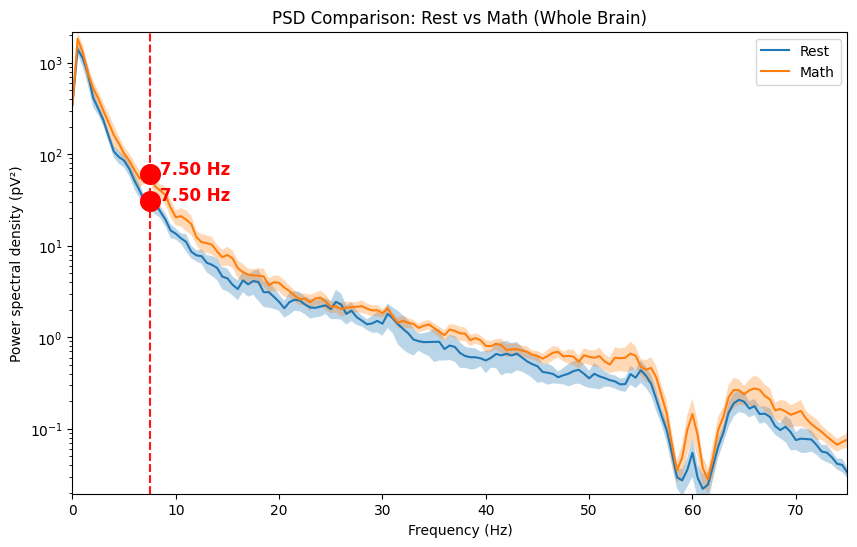

In [65]:
# Full PSD plot for Rest1 vs Math1 focusing on 7.50 Hz

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob

# --- Conditions / folders ---
conditions = ['Rest', 'Math']

# Create folders if they don't exist (optional)
for condition in conditions:
    os.makedirs(condition, exist_ok=True)
print("Directories created for conditions: " + ", ".join(conditions))

# --- Get filenames ---
filenames = {}
for condition in conditions:
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(f"Files for {condition}: {filenames[condition]}")

# --- Experiment parameters ---
sampling_freq = 400
nperseg = 800  # 2-second windows at 400 Hz

# --- Function to generate average PSD ---
def generate_avg_psd(filenames):
    if len(filenames) == 0:
        return np.array([]), np.array([]), np.array([])

    psd_list = []
    freqs = None

    for file in filenames:
        print(f"Processing: {file}")
        columns = ['time', 'recording']
        data = np.genfromtxt(
            file,
            dtype=float,
            usecols=(0,1),
            skip_header=6,
            delimiter='\t',
            names=columns,
            encoding='unicode_escape'
        )
        recording = data['recording']

        # Interpolate NaN values
        nans = np.isnan(recording)
        x = np.arange(len(recording))
        recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

        freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)
        psd_list.append(psd_single)

    # Interpolate PSDs to same length
    max_len = max(len(p) for p in psd_list)
    psd_matrix = np.zeros((max_len, len(psd_list)))
    for i, psd in enumerate(psd_list):
        if len(psd) < max_len:
            psd = np.interp(
                np.linspace(0,1,max_len),
                np.linspace(0,1,len(psd)),
                psd
            )
        psd_matrix[:,i] = psd

    average_psd = np.mean(psd_matrix, axis=1)
    std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(psd_list))  # SEM

    return average_psd, std_psd, freqs

# --- Function to plot PSD ---
def plot_psd(average_psd, std_psd, freqs, label=None):
    plt.semilogy(freqs, average_psd, label=label)
    plt.fill_between(freqs, average_psd - std_psd, average_psd + std_psd, alpha=0.3)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power spectral density (pV²)')
    plt.xlim([0, 75])
    visible_mask = freqs <= 75
    ymin = min((average_psd - std_psd)[visible_mask])
    ymax = max((average_psd + std_psd)[visible_mask])
    plt.ylim(ymin, ymax)

# --- Function to get power near 7.50 Hz ---
def get_power_at_frequency(freqs, psd, target_freq=7.5):
    idx = np.argmin(np.abs(freqs - target_freq))
    return freqs[idx], psd[idx]

# --- Plotting ---
average_psd = {}
std_psd = {}

plt.figure(figsize=(10,6))

for condition in conditions:
    average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])

    if len(average_psd[condition]) == 0:
        print(f"No files found for {condition}")
        continue

    plot_psd(average_psd[condition], std_psd[condition], freqs, label=condition)

    # Highlight 7.50 Hz
    freq_val, power_val = get_power_at_frequency(freqs, average_psd[condition], 7.5)
    print(f"{condition} power near 7.50 Hz: {power_val:.4f}")
    plt.scatter(freq_val, power_val, s=200, color='red', zorder=5)  # big red dot
    plt.text(freq_val + 1, power_val, "7.50 Hz", fontsize=12, fontweight='bold', color='red')
    plt.axvline(x=7.5, color='red', linestyle='--', alpha=0.7)  # vertical line

plt.legend()
plt.title("PSD Comparison: Rest vs Math (Whole Brain)")
plt.show()